In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as pyplot
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)

In [3]:
df1 = pd.read_csv("/content/kathmandu_house_price_10000.csv")
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Plot Area,Ready To Move,Sitapaila,1 BHK,Shanti Residency,602,1,0,68.96
1,Plot Area,18-Oct,Baneshwor,5 Bedroom,Royal Apartments,630,1,0,71.85
2,Super built-up Area,18-Dec,Dhapasi,5 Bedroom,Himalayan Homes,1402,4,2,169.08
3,Built-up Area,Ready To Move,Sanepa,3 BHK,Himalayan Homes,1136,1,1,115.01
4,Built-up Area,Ready To Move,Sitapaila,5 Bedroom,Valley Residency,677,4,2,70.23


In [4]:
df1.shape

(10000, 9)

In [5]:
df1.groupby('area_type')['area_type'].agg('count')

,area_type
area_type,
Built-up Area,3415
Plot Area,3325
Super built-up Area,3260


In [6]:
df2 = df1.drop(['area_type','society','balcony','availability'],axis='columns')
df2.head()

,location,size,total_sqft,bath,price
0,Sitapaila,1 BHK,602,1,68.96
1,Baneshwor,5 Bedroom,630,1,71.85
2,Dhapasi,5 Bedroom,1402,4,169.08
3,Sanepa,3 BHK,1136,1,115.01
4,Sitapaila,5 Bedroom,677,4,70.23


In [7]:
df2.isnull().sum()

,0
location,0
size,0
total_sqft,0
bath,0
price,0


In [8]:
df3 = df2.dropna()
df3.isnull().sum()


,0
location,0
size,0
total_sqft,0
bath,0
price,0


In [9]:
df3.shape

(10000, 5)

In [10]:
df3['size'].unique()

array(['1 BHK', '5 Bedroom', '3 BHK', '2 BHK', '4 BHK'], dtype=object)

In [12]:
df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))

In [13]:
df3.head()

,location,size,total_sqft,bath,price,bhk
0,Sitapaila,1 BHK,602,1,68.96,1
1,Baneshwor,5 Bedroom,630,1,71.85,5
2,Dhapasi,5 Bedroom,1402,4,169.08,5
3,Sanepa,3 BHK,1136,1,115.01,3
4,Sitapaila,5 Bedroom,677,4,70.23,5


In [14]:
df3['bhk'].unique()

array([1, 5, 3, 2, 4])

In [15]:
df3[df3.bhk>20]

,location,size,total_sqft,bath,price,bhk


In [16]:
df3.total_sqft.unique()

array([ 602,  630, 1402, ..., 2356,  930,  708])

In [17]:
def is_float(x):
  try:
    float(x)
  except:
    return False
  return True

In [18]:
df3[~df3['total_sqft'].apply(is_float)].head()

,location,size,total_sqft,bath,price,bhk


In [24]:
def convert_sqft_to_num(x):
  # Ensure x is a string before splitting, to handle int/float inputs gracefully
  s = str(x)
  token = s.split('-')
  if len(token) == 2:
    try:
      return (float(token[0])+float(token[1]))/2
    except ValueError:
      return None # Handle cases like 'abc-def'
  try:
    return float(s)
  except ValueError:
    return None

In [25]:
df4 = df3.copy()
df4['total_sqft'] = df4['total_sqft'].apply(convert_sqft_to_num)
df4.head(3)

,location,size,total_sqft,bath,price,bhk
0,Sitapaila,1 BHK,602.0,1,68.96,1
1,Baneshwor,5 Bedroom,630.0,1,71.85,5
2,Dhapasi,5 Bedroom,1402.0,4,169.08,5


In [26]:
df4.loc[30]

,30
location,Sitapaila
size,2 BHK
total_sqft,1277.0
bath,2
price,251.0
bhk,2


In [27]:
df4.head(3)

,location,size,total_sqft,bath,price,bhk
0,Sitapaila,1 BHK,602.0,1,68.96,1
1,Baneshwor,5 Bedroom,630.0,1,71.85,5
2,Dhapasi,5 Bedroom,1402.0,4,169.08,5


In [28]:
df5 = df4.copy()
df5['price_per_sqft'] = df5['price']*100000/df5['total_sqft']
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Sitapaila,1 BHK,602.0,1,68.96,1,11455.149502
1,Baneshwor,5 Bedroom,630.0,1,71.85,5,11404.761905
2,Dhapasi,5 Bedroom,1402.0,4,169.08,5,12059.914408
3,Sanepa,3 BHK,1136.0,1,115.01,3,10124.119718
4,Sitapaila,5 Bedroom,677.0,4,70.23,5,10373.707533


In [29]:
len(df5.location.unique())

20

In [30]:
df5.location = df5.location.apply(lambda x: x.strip())
location_stats = df5.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats

,location
location,
Tokha,540
Gongabu,536
Kalanki,523
Baneshwor,516
Boudha,511
Pepsicola,510
Sanepa,507
Koteshwor,504
Lalitpur,502


In [31]:
len(location_stats[location_stats<=10])

0

In [32]:
location_stats_less_than_10 = location_stats[location_stats<=10]
location_stats_less_than_10

,location
location,


In [33]:
len(df5.location.unique())

20

In [34]:
df5.location = df5.location.apply(lambda x: 'other' if x in location_stats_less_than_10 else x)
len(df5.location.unique())

20

In [35]:
df5.head(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Sitapaila,1 BHK,602.0,1,68.96,1,11455.149502
1,Baneshwor,5 Bedroom,630.0,1,71.85,5,11404.761905
2,Dhapasi,5 Bedroom,1402.0,4,169.08,5,12059.914408
3,Sanepa,3 BHK,1136.0,1,115.01,3,10124.119718
4,Sitapaila,5 Bedroom,677.0,4,70.23,5,10373.707533
5,Bhaisepati,5 Bedroom,2864.0,2,279.67,5,9765.013966
6,Sanepa,2 BHK,913.0,2,127.71,2,13987.951807
7,Kirtipur,2 BHK,3245.0,2,626.39,2,19303.235747
8,Sitapaila,5 Bedroom,1169.0,4,139.92,5,11969.204448
9,Patan,3 BHK,729.0,1,130.17,3,17855.967078


In [36]:
df5.shape

(10000, 7)

In [37]:
df6 = df5[~(df5.total_sqft/df5.bhk<300)]
df6.shape

(8513, 7)

In [38]:
df6.price_per_sqft.describe()

,price_per_sqft
count,8513.000000
mean,14496.723836
std,3202.893143
min,9000.606980
25%,11723.569350
50%,14478.697505
75%,17310.176125
max,19998.251748


In [39]:
def remove_pps_outliers(df):
  df_out = pd.DataFrame()
  for key, subdf in df.groupby('location'):
    m = np.mean(subdf.price_per_sqft)
    st = np.std(subdf.price_per_sqft)
    reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
    df_out = pd.concat([df_out,reduced_df],ignore_index=True)
  return df_out

df7 = remove_pps_outliers(df6)
df7.shape

(4906, 7)

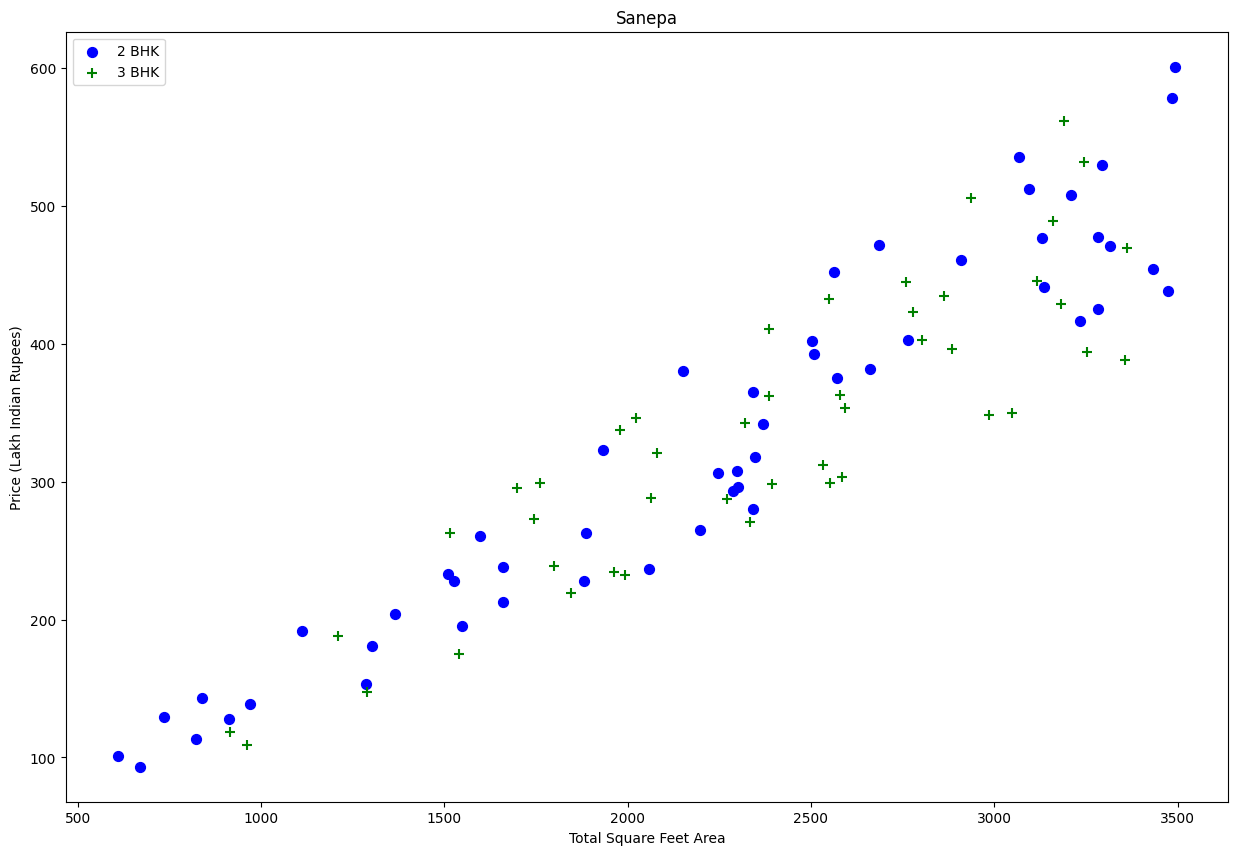

In [40]:
import matplotlib
from matplotlib import pyplot as pyplot

def plot_scatter_chart(df,location):
  bhk2 = df[(df.location == location) & (df.bhk == 2)]
  bhk3 = df[(df.location == location) & (df.bhk == 3)]
  matplotlib.rcParams['figure.figsize'] = (15,10)
  pyplot.scatter(bhk2.total_sqft,bhk2.price,color='blue',label='2 BHK', s=50)
  pyplot.scatter(bhk3.total_sqft,bhk3.price,marker='+', color='green',label='3 BHK', s=50)
  pyplot.xlabel("Total Square Feet Area")
  pyplot.ylabel("Price (Lakh Indian Rupees)")
  pyplot.title(location)
  pyplot.legend()

plot_scatter_chart(df7,"Sanepa")

In [41]:
def remove_bhk_outliers(df):
  exclude_indices = np.array([])
  for location, location_df in df.groupby('location'):
    bhk_stats = {}
    for bhk, bhk_df in location_df.groupby('bhk'):
      bhk_stats[bhk] = {
          'mean': np.mean(bhk_df.price_per_sqft),
          'std': np.std(bhk_df.price_per_sqft),
          'count': bhk_df.shape[0]
      }
    for bhk, bhk_df in location_df.groupby('bhk'):
      stats = bhk_stats.get(bhk-1)
      if stats and stats['count']>5:
        exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
  return df.drop(exclude_indices,axis='index')

df8 = remove_bhk_outliers(df7)
df8.shape

(3036, 7)

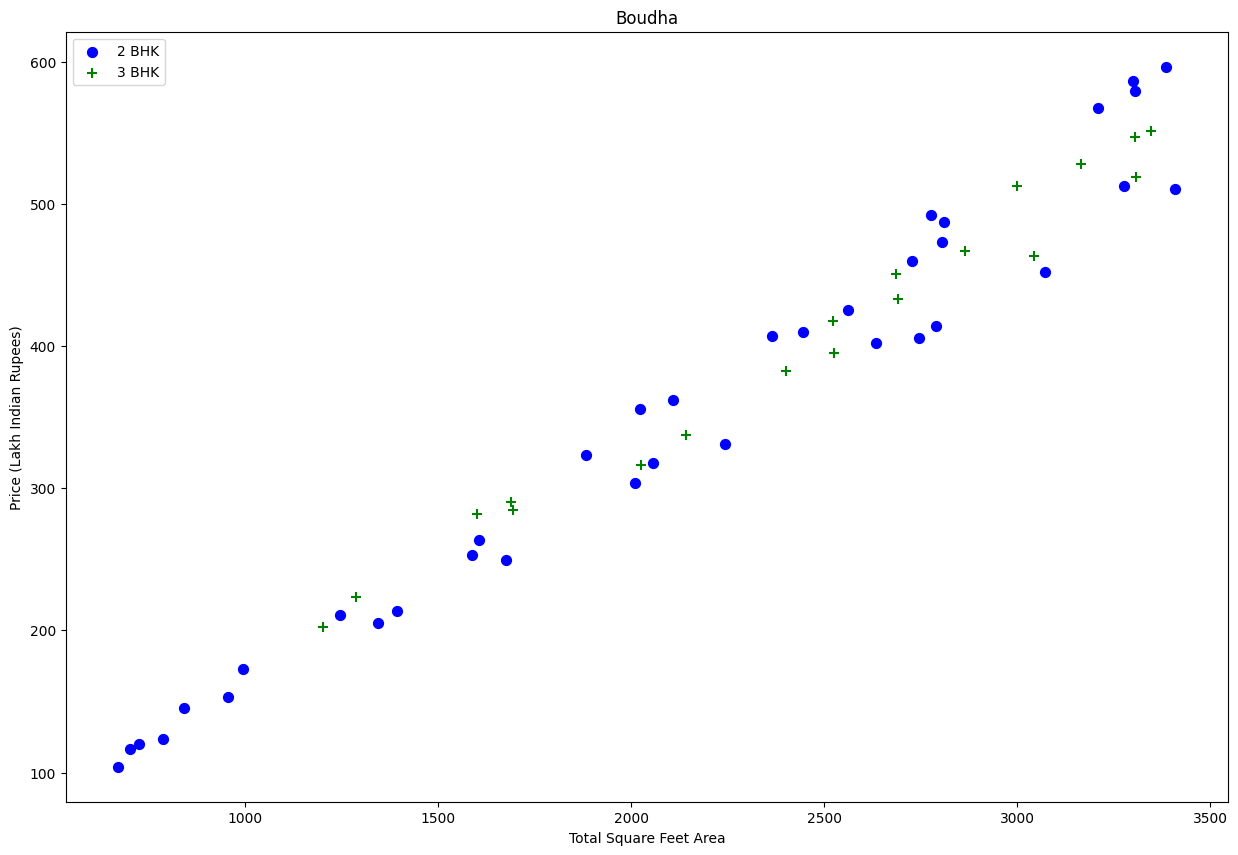

In [42]:
plot_scatter_chart(df8,"Boudha")

Text(0, 0.5, 'Count')

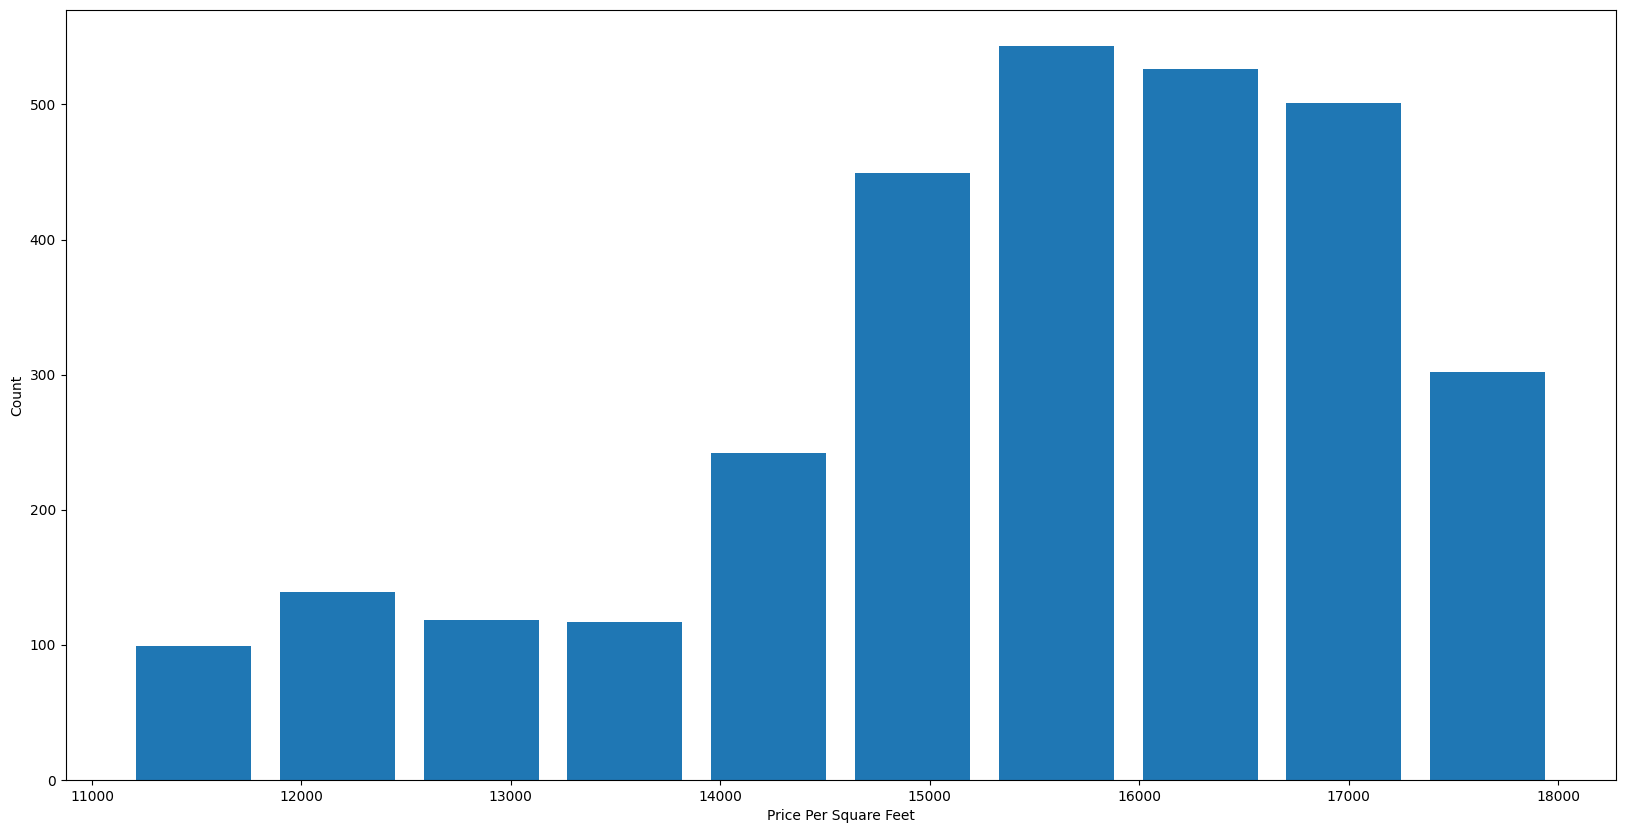

In [43]:
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)
pyplot.hist(df8.price_per_sqft,rwidth=0.8)
pyplot.xlabel("Price Per Square Feet")
pyplot.ylabel("Count")


In [44]:
df8.bath.unique()

array([1, 2, 4, 3, 5])

In [45]:
df8[df8.bath>10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft


Text(0, 0.5, 'Count')

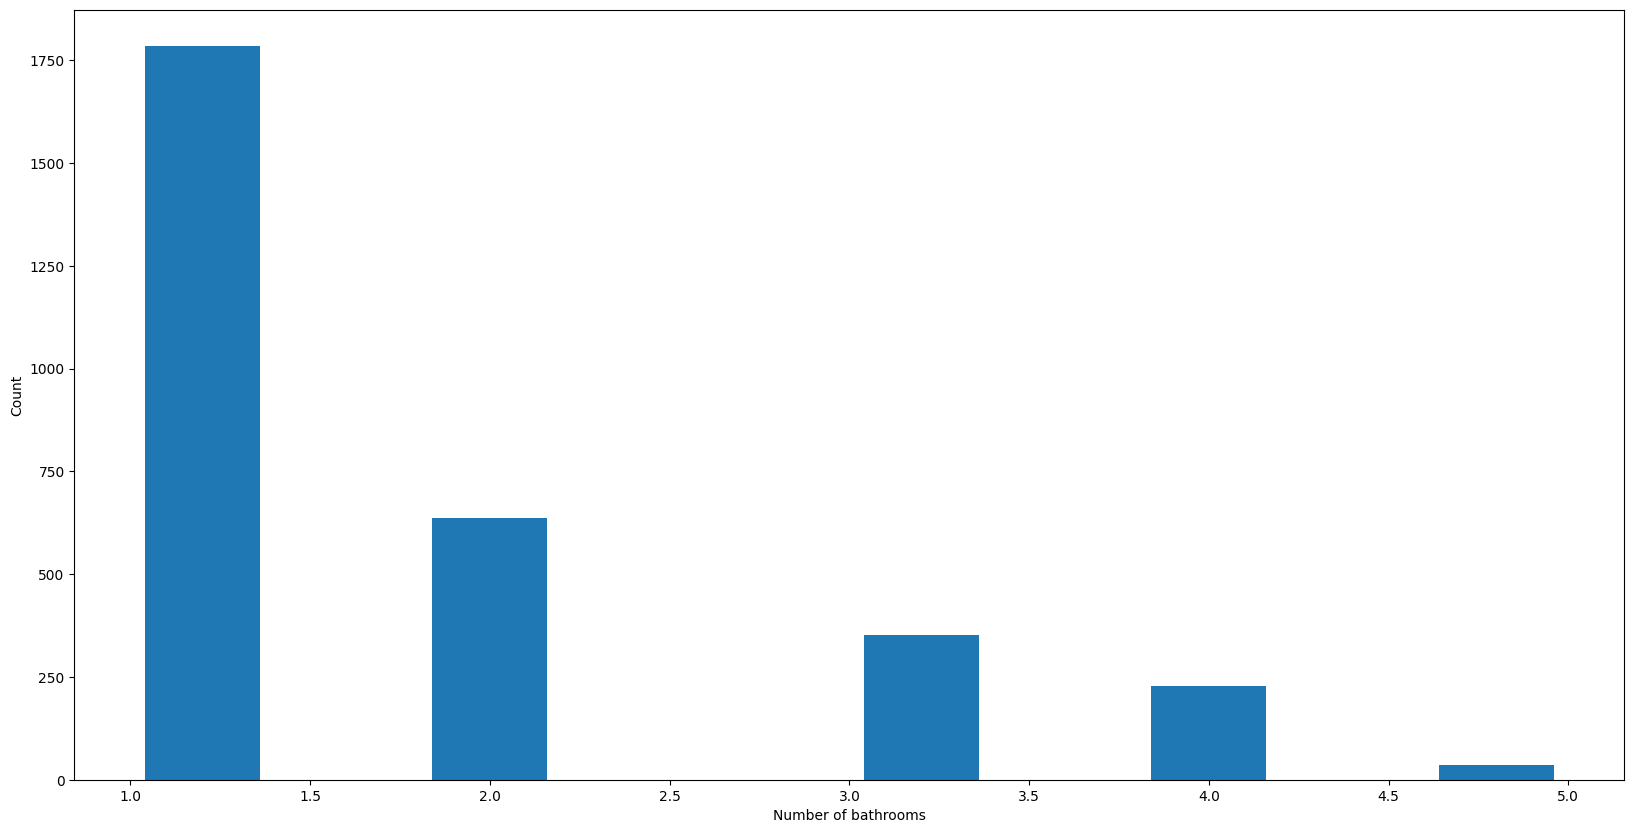

In [46]:
pyplot.hist(df8.bath,rwidth=0.8)
pyplot.xlabel("Number of bathrooms")
pyplot.ylabel("Count")

In [47]:
df9 = df8[df8.bath<=df8.bhk+2]
df9.shape

(3036, 7)

In [48]:
df10 = df9.drop(['size','price_per_sqft'],axis='columns')
df10.head(3)

,location,total_sqft,bath,price,bhk
0,Baluwatar,3036.0,1,492.78,5
1,Baluwatar,3198.0,1,469.15,2
5,Baluwatar,1337.0,1,233.18,1


In [49]:
dummies = pd.get_dummies(df10.location)
dummies.head(3)

,Baluwatar,Baneshwor,Bhaisepati,Bhaktapur,Boudha,Budhanilkantha,Chabahil,Dhapasi,Gongabu,Imadol,Kalanki,Kirtipur,Koteshwor,Lalitpur,Patan,Pepsicola,Samakhusi,Sanepa,Sitapaila,Tokha
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [51]:
df11 =pd.concat([df10,dummies],axis='columns')
df11.head()

,location,total_sqft,bath,price,bhk,Baluwatar,Baneshwor,Bhaisepati,Bhaktapur,Boudha,...,Kalanki,Kirtipur,Koteshwor,Lalitpur,Patan,Pepsicola,Samakhusi,Sanepa,Sitapaila,Tokha
0,Baluwatar,3036.0,1,492.78,5,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Baluwatar,3198.0,1,469.15,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,Baluwatar,1337.0,1,233.18,1,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,Baluwatar,1912.0,1,310.28,1,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,Baluwatar,2351.0,1,326.70,1,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [52]:
df12 = df11.drop('location',axis='columns')
df12.head(2)

,total_sqft,bath,price,bhk,Baluwatar,Baneshwor,Bhaisepati,Bhaktapur,Boudha,Budhanilkantha,...,Kalanki,Kirtipur,Koteshwor,Lalitpur,Patan,Pepsicola,Samakhusi,Sanepa,Sitapaila,Tokha
0,3036.0,1,492.78,5,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3198.0,1,469.15,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [53]:
x = df12.drop(['price'],axis='columns')
x.head(3)

,total_sqft,bath,bhk,Baluwatar,Baneshwor,Bhaisepati,Bhaktapur,Boudha,Budhanilkantha,Chabahil,...,Kalanki,Kirtipur,Koteshwor,Lalitpur,Patan,Pepsicola,Samakhusi,Sanepa,Sitapaila,Tokha
0,3036.0,1,5,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3198.0,1,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,1337.0,1,1,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [54]:
y = df12.price
y.head()

,price
0,492.78
1,469.15
5,233.18
7,310.28
8,326.70


In [55]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [56]:
from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(x_train,y_train)
lr_clf.score(x_test,y_test)

0.9462687367794679

In [57]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(), x, y, cv=cv)

array([0.93599735, 0.93947498, 0.94190412, 0.94143429, 0.93942777])

In [58]:
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

def find_best_model_using_gridsearchcv(x,y):
  algos = {
      'linear_regression' : {
          'model': LinearRegression(),
          'params': {
              # 'normalize': [True, False] # 'normalize' parameter is deprecated and removed in recent sklearn versions
              'fit_intercept': [True, False] # A valid parameter for LinearRegression
          }
      },
      'lasso': {
          'model': Lasso(),
          'params': {
              'alpha': [1,2],
              'selection': ['random', 'cyclic']
          }
      },
      'decision_tree': {
          'model': DecisionTreeRegressor(),
          'params': {
              'criterion' : ['mse','friedman_mse'],
              'splitter': ['best','random']
          }
      }
  }
  scores = []
  cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
  for algo_name, config in algos.items():
    gs =  GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
    gs.fit(x,y)
    scores.append({
        'model': algo_name,
        'best_score': gs.best_score_,
        'best_params': gs.best_params_
    })

  return pd.DataFrame(scores,columns=['model','best_score','best_params'])

find_best_model_using_gridsearchcv(x,y)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

,model,best_score,best_params
0,linear_regression,0.939648,{'fit_intercept': True}
1,lasso,0.939108,"{'alpha': 1, 'selection': 'cyclic'}"
2,decision_tree,0.890008,"{'criterion': 'friedman_mse', 'splitter': 'ran..."


In [59]:
x.columns

Index(['total_sqft', 'bath', 'bhk', 'Baluwatar', 'Baneshwor', 'Bhaisepati',
       'Bhaktapur', 'Boudha', 'Budhanilkantha', 'Chabahil', 'Dhapasi',
       'Gongabu', 'Imadol', 'Kalanki', 'Kirtipur', 'Koteshwor', 'Lalitpur',
       'Patan', 'Pepsicola', 'Samakhusi', 'Sanepa', 'Sitapaila', 'Tokha'],
      dtype='object')

In [60]:
def predict_price(location,sqft,bath,bhk):
  # Reference the global x DataFrame for column names
  loc_index = np.where(x.columns==location)[0][0]

  # Create a new local variable for the input array
  x_input = np.zeros(len(x.columns))
  x_input[0] = sqft
  x_input[1] = bath
  x_input[2] = bhk
  if loc_index >= 0:
    x_input[loc_index] = 1

  return lr_clf.predict([x_input])[0]

In [61]:
predict_price('Bhaktapur',1000, 2, 2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(155.2523814253153)

In [62]:
predict_price('Patan',1000, 3, 3)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(173.21577000259293)

In [63]:
import pickle
with open('kathmandu_home_prices_model.pickle','wb') as f:
  pickle.dump(lr_clf,f)

In [64]:
import json
columns = {
    'data_columns' : [col.lower() for col in x.columns]
}
with open("columns.json","w") as f:
  f.write(json.dumps(columns))
